In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic uncleaned (2).csv")


In [60]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [61]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [62]:
df.shape

(418, 12)

In [63]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [65]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [66]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.nunique()

,0
PassengerId,418
Survived,2
Pclass,3
Name,418
Sex,2
Age,79
SibSp,7
Parch,8
Ticket,363
Fare,169


In [69]:
df["Sex"].unique()
df["Embarked"].unique()

array(['Q', 'S', 'C'], dtype=object)

In [70]:
df.columns = df.columns.str.strip()

In [71]:
df = df.drop_duplicates()

In [72]:
text_columns = ["Name", "Sex", "Ticket", "Cabin", "Embarked"]

for col in text_columns:
    df[col] = df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

In [73]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [74]:
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [75]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [76]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


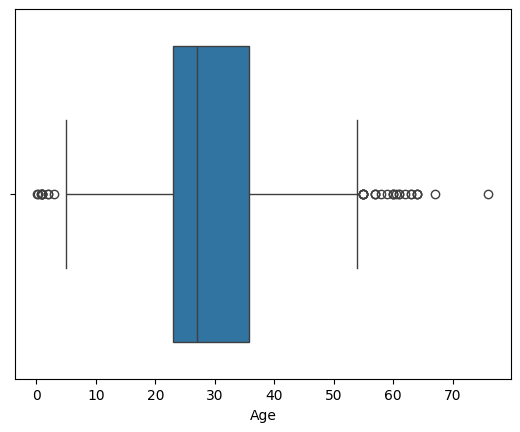

In [77]:
sns.boxplot(x=df["Age"])
plt.show()

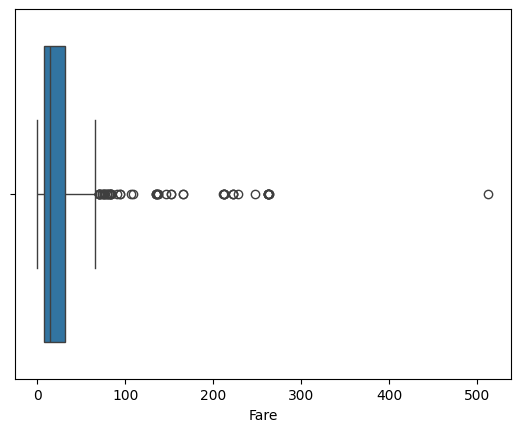

In [78]:
sns.boxplot(x=df["Fare"])
plt.show()

In [79]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [80]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    dtype=int
)

In [81]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [82]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [83]:
df = df.drop(
    columns=["Name", "Ticket", "Cabin"]
)

In [84]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_C,0
Embarked_Q,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Sex          418 non-null    int64  
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Fare         418 non-null    float64
 8   Embarked_C   418 non-null    int64  
 9   Embarked_Q   418 non-null    int64  
 10  Embarked_S   418 non-null    int64  
 11  FamilySize   418 non-null    int64  
 12  IsAlone      418 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 42.6 KB


In [86]:
df.shape

(418, 13)

In [87]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,892,0,3,0,34.5,0,0,7.8292,0,1,0,1,1
1,893,1,3,1,47.0,1,0,7.0000,0,0,1,2,0
2,894,0,2,0,62.0,0,0,9.6875,0,1,0,1,1
3,895,0,3,0,27.0,0,0,8.6625,0,0,1,1,1
4,896,1,3,1,22.0,1,1,12.2875,0,0,1,3,0


In [88]:
df.to_csv("titanic_preprocessed.csv", index=False)

In [89]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (418, 13)

Missing values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
FamilySize     0
IsAlone        0
dtype: int64

Duplicate rows:
0

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
FamilySize       int64
IsAlone          int64
dtype: object
